In [11]:
print("Radha!")

Radha!


In [12]:
import os
import uuid
from typing import TypedDict, List, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.store.memory import InMemoryStore
from langgraph.graph import StateGraph, START, END

load_dotenv()

True

In [13]:
# ============================================================
# 1. CONSTANTS & SAFETY LIMITS
# ============================================================
MAX_REVISIONS = 3  # Hard limit on revision loop count

# Capping max_tokens stops long-winded output and reduces token consumption
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.7,
    max_tokens=500
)

# Initialize Long-Term Memory Store for Fitness & Health Profiles
store = InMemoryStore()
NAMESPACE = ("fitness_profile",)

In [14]:
# ============================================================
# 2. LONG-TERM MEMORY HELPER FUNCTIONS
# ============================================================

def get_fitness_profile(user_id: str):
    """Retrieve user's static fitness profile from memory store."""
    memories = store.search((user_id, *NAMESPACE))
    if not memories:
        return None
    return memories[0].value

def extract_fitness_memory(message: str) -> str:
    """Extracts critical health, injury, diet, and training facts from user chat."""
    prompt = f"""You are a memory extraction engine for a Personalized Fitness Coach.

Analyze this user message:
"{message}"

Extract only critical personal facts that must be remembered long-term.
Useful details include:
- Physical injuries or medical limits (e.g., knee pain, lower back injury)
- Dietary preferences & allergies (e.g., lactose intolerant, vegetarian, keto)
- Fitness goals (e.g., muscle gain, marathon training, weight loss)
- Available equipment & preferred training style (e.g., home gym, dumbell-only, 30-min workouts)

If there is nothing persistent to remember, return exactly: NONE
Return only the concise extracted fact.
"""
    response = llm.invoke([
        SystemMessage(content="Extract persistent user fitness and health facts accurately."),
        HumanMessage(content=prompt)
    ])
    return response.content.strip()

def save_fitness_memory(user_id: str, memory: str):
    """Stores extracted fitness memory under a unique UUID for a given user."""
    if not memory or memory.upper() == "NONE":
        return
    
    memory_id = str(uuid.uuid4())
    store.put(
        (user_id, *NAMESPACE), 
        memory_id, 
        {"value": memory}
    )

def get_all_fitness_memories(user_id: str) -> List[str]:
    """Retrieves all stored health and fitness facts for a specific user ID."""
    memories = store.search((user_id, *NAMESPACE))
    return [
        mem.value["value"] 
        for mem in memories 
        if isinstance(mem.value, dict) and "value" in mem.value
    ]

def update_fitness_memory(user_id: str, keyword: str, new_memory: str):
    """Updates existing health/fitness memory matching a keyword to handle recovered injuries or diet changes."""
    memories = store.search((user_id, *NAMESPACE))
    for memory in memories:
        val = memory.value.get("value", "") if isinstance(memory.value, dict) else ""
        if keyword.lower() in val.lower():
            store.put(
                (user_id, *NAMESPACE), 
                memory.key, 
                {"value": new_memory}
            )
            print(f"✅ Fitness memory matching '{keyword}' updated.")
            return
    print("❌ No matching memory found to update.")

def delete_fitness_memory(user_id: str, keyword: str):
    """Deletes fitness memory entries when preferences or limitations are removed."""
    memories = store.search((user_id, *NAMESPACE))
    for memory in memories:
        val = memory.value.get("value", "") if isinstance(memory.value, dict) else ""
        if keyword.lower() in val.lower():
            store.delete((user_id, *NAMESPACE), memory.key)
            print(f"🗑️ Memory matching '{keyword}' deleted.")
            return
    print("❌ No matching memory found to delete.")

def build_fitness_context(user_id: str) -> str:
    """Formats stored user health and training preferences into a context string."""
    memories = get_all_fitness_memories(user_id)
    if not memories:
        return "No prior health or fitness context stored."
    return "\n".join(f"- {m}" for m in memories)

In [15]:
# ============================================================
# 3. STRUCTURED SCHEMAS & SHARED STATE
# ============================================================

class SupervisorDecision(BaseModel):
    """Structured decision schema for supervisor routing."""
    next_agent: Literal["planner", "safety_reviewer", "final", "end"] = Field(
        description="The next agent to execute, or 'end' if workout/diet plan is published."
    )
    reasoning: str = Field(
        description="Brief explanation of supervisor routing choice."
    )

supervisor_llm = llm.with_structured_output(SupervisorDecision)

class FitnessState(TypedDict):
    user_id: str
    request: str
    draft: str
    review: str
    review_status: str  # "APPROVED" or "NEEDS_REVISION"
    final_post: str
    next_agent: str
    revision_count: int

In [16]:
# ============================================================
# 4. WORKER AGENTS
# ============================================================

def fitness_planner_agent(state: FitnessState) -> dict:
    """Generates workout or meal routine strictly adhering to user's long-term memory constraints."""
    user_id = state.get("user_id", "user_101")
    memory_context = build_fitness_context(user_id)

    feedback_context = ""
    if state.get("review") and state.get("review_status") == "NEEDS_REVISION":
        feedback_context = f"\n\nAddress Safety Feedback:\n{state['review']}"

    prompt = f"""You are an expert Personal Fitness & Nutrition Coach.
User Request: {state['request']}

USER LONG-TERM HEALTH & FITNESS PROFILE:
{memory_context}{feedback_context}

Requirements:
- Ensure 100% compliance with user's injuries, dietary restrictions, and goal style
- Provide clean bulleted steps or meal options
- Be encouraging, direct, and concise
"""
    response = llm.invoke([
        SystemMessage(content="You generate safe, personalized fitness and meal routines."),
        HumanMessage(content=prompt)
    ])
    
    current_revisions = state.get("revision_count", 0)
    
    return {
        "draft": str(response.content),
        "review": "",
        "review_status": "",
        "revision_count": current_revisions + 1
    }


def safety_reviewer_agent(state: FitnessState) -> dict:
    """Reviews draft routines against stored long-term memory constraints (e.g., checking for forbidden exercises/ingredients)."""
    user_id = state.get("user_id", "user_101")
    memory_context = build_fitness_context(user_id)

    prompt = f"""You are a Sports Medicine & Dietary Safety Auditor.
Evaluate this routine against the user's health profile constraints.

USER PROFILE CONSTRAINTS:
{memory_context}

PROPOSED DRAFT:
{state['draft']}

Check strictly: Does the draft contain exercises that endanger user injuries or ingredients that breach dietary limits?

Provide evaluation in exact format:
STATUS: [APPROVED or NEEDS_REVISION]
FEEDBACK: [1-2 concise actionable corrections if unsafe, otherwise state 'Safe to proceed']
"""
    response = llm.invoke([
        SystemMessage(content="You evaluate physical safety and dietary compliance objectively."),
        HumanMessage(content=prompt)
    ])
    
    content = str(response.content)
    status = "APPROVED" if "STATUS: APPROVED" in content.upper() else "NEEDS_REVISION"
    
    return {
        "review": content,
        "review_status": status
    }


def final_agent(state: FitnessState) -> dict:
    """Formats the approved workout or nutrition guide for direct user presentation."""
    prompt = f"""You are a head fitness coach editor.
Polish the following approved plan for direct user delivery:

DRAFT:
{state['draft']}

Return ONLY the polished plan without meta-commentary.
"""
    response = llm.invoke([
        SystemMessage(content="You format finalized fitness plans."),
        HumanMessage(content=prompt)
    ])
    
    return {"final_post": str(response.content)}

In [17]:
# ============================================================
# 5. SUPERVISOR & ROUTING (SAFETY ENFORCED)
# ============================================================

def supervisor(state: FitnessState) -> dict:
    """Evaluates state and controls fitness workflow progression with safety boundaries."""
    
    # 1. IMMEDIATE EXIT GUARD: Terminate if response plan is complete
    if state.get("final_post"):
        return {"next_agent": "end"}

    # 2. REVISION LIMIT GUARD: Stop infinite loops at MAX_REVISIONS limit
    if state.get("revision_count", 0) >= MAX_REVISIONS and state.get("draft"):
        return {"next_agent": "final"}

    system_prompt = """You are the AI Fitness Workflow Supervisor.
Choose the next step strictly based on current state:

- 'planner': If no draft exists OR if review_status is 'NEEDS_REVISION'.
- 'safety_reviewer': If a draft exists AND review_status is empty/cleared.
- 'final': If review_status is 'APPROVED'.
- 'end': If final_post is complete.
"""

    state_summary = f"""State Summary:
- Has Draft: {bool(state.get('draft'))}
- Review Status: '{state.get('review_status', '')}'
- Has Final Plan: {bool(state.get('final_post'))}
- Current Revision Count: {state.get('revision_count', 0)} / {MAX_REVISIONS}
"""

    decision: SupervisorDecision = supervisor_llm.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=state_summary)
    ])
    
    # Map decision to state structure
    next_step = decision.next_agent
    if next_step == "writer":
        next_step = "planner"
    elif next_step == "reviewer":
        next_step = "safety_reviewer"
        
    return {"next_agent": next_step}


def route_to_agent(state: FitnessState) -> Literal["planner", "safety_reviewer", "final", "end"]:
    """Conditional router function."""
    return state["next_agent"]

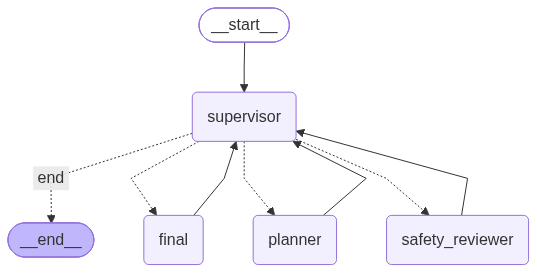

In [18]:
# ============================================================
# 6. GRAPH BUILD
# ============================================================

builder = StateGraph(FitnessState)

builder.add_node("supervisor", supervisor)
builder.add_node("planner", fitness_planner_agent)
builder.add_node("safety_reviewer", safety_reviewer_agent)
builder.add_node("final", final_agent)

builder.add_edge(START, "supervisor")

builder.add_conditional_edges(
    "supervisor",
    route_to_agent,
    {
        "planner": "planner",
        "safety_reviewer": "safety_reviewer",
        "final": "final",
        "end": END
    }
)

builder.add_edge("planner", "supervisor")
builder.add_edge("safety_reviewer", "supervisor")
builder.add_edge("final", "supervisor")

graph = builder.compile()
graph

In [19]:
# ============================================================
# 7. SAFE EXECUTION & REAL-WORLD FITNESS MEMORY DEMO
# ============================================================

# Step 1: Simulate prior user sessions storing long-term memory facts
print("💾 Initializing Long-Term Health & Fitness Memory Store...")

user_id = "athlete_42"

# Session 1 Memory
m1 = extract_fitness_memory("I broke my right knee last year and cannot do heavy barbell squats or jumping exercises.")
save_fitness_memory(user_id, m1)

# Session 2 Memory
m2 = extract_fitness_memory("I recently went strict lactose-free vegan and want high protein meals.")
save_fitness_memory(user_id, m2)

print("\n--- Stored Long-Term Profile Context ---")
print(build_fitness_context(user_id))
print("=" * 55 + "\n")

# Step 2: New Session Request (User doesn't repeat their injury or diet limits!)
initial_state: FitnessState = {
    "user_id": user_id,
    "request": "Give me a quick 20-minute leg workout and a post-workout recovery snack.",
    "draft": "",
    "review": "",
    "review_status": "",
    "final_post": "",
    "next_agent": "",
    "revision_count": 0
}

print("🚀 Executing Multi-Agent System with Long-Term Memory Context...\n")

config = {"recursion_limit": 8}

try:
    for event in graph.stream(initial_state, config=config):
        for node_name, state_update in event.items():
            print(f"--- Executed Node: {node_name} ---")
            if "next_agent" in state_update:
                print(f"Supervisor Decision -> {state_update['next_agent']}")
            elif "review_status" in state_update:
                print(f"Safety Review Verdict -> {state_update['review_status']}")
            elif "revision_count" in state_update:
                print(f"Revision Pass -> {state_update['revision_count']}/{MAX_REVISIONS}")
            print()

    # Retrieve completed response
    final_result = graph.invoke(initial_state, config=config)
    
    print("\n" + "="*20 + " PERSONALIZED FITNESS OUTPUT " + "="*20 + "\n")
    print(final_result.get("final_post", "No plan generated."))
    print("\n" + "="*62)

except Exception as err:
    print(f"Workflow stopped safely: {err}")

💾 Initializing Long-Term Health & Fitness Memory Store...

--- Stored Long-Term Profile Context ---
- - Broken right knee, cannot do heavy barbell squats or jumping exercises.
- - Dietary preference: strict lactose-free vegan
- Fitness goal: high protein meals

🚀 Executing Multi-Agent System with Long-Term Memory Context...

--- Executed Node: supervisor ---
Supervisor Decision -> planner

--- Executed Node: planner ---
Safety Review Verdict -> 

--- Executed Node: supervisor ---
Supervisor Decision -> safety_reviewer

--- Executed Node: safety_reviewer ---
Safety Review Verdict -> APPROVED

--- Executed Node: supervisor ---
Supervisor Decision -> final

--- Executed Node: final ---

--- Executed Node: supervisor ---
Supervisor Decision -> end


==================== PERSONALIZED FITNESS OUTPUT ====================

### 20-Minute Leg Workout (Low Impact)

**Warm-Up (3 minutes)**
- **Leg Swings**: 1 minute (30 seconds each leg)
- **Dynamic Stretching**: 2 minutes (focus on hamstrings, qu